# 02 — Attribution и ROMI

На вход: `outputs/orders.csv` из ноутбука 01 и `data/posts.csv`, собранный скриптом
`src/collect_posts.py` из публичного веб-превью Telegram.

## Про данные

| Слой | Источник | Статус |
|---|---|---|
| Заказы, выручка, даты | `base.xlsx` от организаторов | **реальные** |
| Публикации канала: даты, тексты, охваты | `t.me/s/postypashki_old`, собраны нами | **реальные** |
| Внешние упоминания: каналы, даты, охваты | TGStat, собраны командой | **реальные** |
| Тип публикации (SALE / DISCOUNT / LAUNCH) | rule-based классификатор по тексту | **вывод**, не факт |
| Стоимость размещений (`cost`) | восстановлена по CPM, журнала закупок нет | **синтетика** |
| Привязка касания к конкретному пользователю | сгенерирована | **синтетика** |

Ключевое отличие от первой версии: **даты и типы маркетинговых событий больше не выдуманы**.
Синтетическим остался ровно один слой — кто именно из покупателей какое касание получил.
Это и есть то, что перестанет быть синтетикой, как только бот начнёт писать `bot_start`
с параметром `source`.

In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

ROOT = next(p for p in [Path(".."), Path(".")] if (p / "outputs").exists())
OUT, DATA = ROOT / "outputs", ROOT / "data"

orders = pd.read_csv(OUT / "orders.csv", parse_dates=["ts"])
posts = pd.read_csv(DATA / "posts.csv", parse_dates=["date"])
posts["ts"] = pd.to_datetime(posts["datetime"], utc=True, format="mixed").dt.tz_localize(None)

if "recovered" not in posts.columns:
    posts["recovered"] = False
posts["recovered"] = posts.recovered.fillna(False).astype(bool)

# у восстановленного поста охвата нет — TGStat отдал текст, но не просмотры.
# для весов в генераторе касаний подставляем медиану, это допущение
posts["views_filled"] = posts.views.fillna(posts.views.median())

print(f"заказов: {len(orders)}, из них повторных: {orders.is_repeat.sum()}")
print(f"постов: {len(posts)}, период {posts.date.min():%d.%m} - {posts.date.max():%d.%m}")
print(f"из них восстановлено из удалённых: {posts.recovered.sum()}")

заказов: 625, из них повторных: 19
постов: 58, период 01.08 - 10.09
из них восстановлено из удалённых: 1


## 1. Классификация публикаций

Правила, а не модель: организаторы прямо пишут, что нейросеть сама по себе преимуществом
не является, а простой работающий инструмент может дать больше баллов.

Главная ловушка при разметке — слово «старт». Это и название их курсов («Аналитика старт»),
и обычное слово («старт отбора на стажировку»). Поэтому признак «пост про наш продукт»
привязан к **реальным названиям курсов из `base.xlsx`**, а не к словарю на глаз.

In [6]:
courses = pd.read_excel(DATA / "base.xlsx")["Курс"].unique()
COURSE_TOKENS = [tuple(c.lower().split()) for c in courses]

BRAND = [r"наш[аиегоих]*\s+курс", r"наши курсы", r"на курс[еах]?\b", r"поток[еа]?\b",
         r"учениц?[аые]", r"выпускник", r"распродаж", r"линейк", r"доступ к курс",
         r"старт[ае] обучени", r"тариф"]

THIRD_PARTY = [r"\berid\b", r"рекламодател", r"дайджест вакансий",
               r"подборка вакансий", r"\bооо\b", r"партнёрск", r"партнерск"]

RULES = [
    # метка,      паттерны,                                          нужен ли свой продукт
    ("NATIVE",   THIRD_PARTY,                                        False),
    # акция не обязана называться скидкой: бывает дедлайн плюс зачёркнутая
    # якорная цена — ровно так была оформлена сентябрьская распродажа
    ("DISCOUNT", [r"скидк", r"распродаж", r"промокод", r"-\s?\d{1,2}\s?%",
                  r"только до \d{1,2}\.\d{2}", r"₽\s*(?:->|→|➡)",
                  r"цена за (?:один |любой )?курс"],                 True),
    ("LAUNCH",   [r"запускаем", r"открываем набор", r"новая линейка",
                  r"новый курс", r"выходим на новый уровень"],       True),
    # призыв к действию — более надёжный признак продажи, чем слово "купить"
    ("SALE",     [r"купит", r"оплат", r"осталось мест", r"набор на", r"записать",
                  r"пишите менеджеру", r"написать администратору", r"пишите в личку",
                  r"доступ к курс", r"успей"],                       True),
]


def mentions_own_product(low: str) -> bool:
    if any(re.search(p, low) for p in BRAND):
        return True
    return any(all(t in low for t in toks) for toks in COURSE_TOKENS)


def classify(text: str) -> str:
    low = str(text).lower()
    own = mentions_own_product(low)
    for label, patterns, needs_own in RULES:
        if any(re.search(p, low) for p in patterns):
            if needs_own and not own:
                continue
            return label
    return "CONTENT"


posts["post_type"] = posts.text.map(classify)
print("после правил:")
print(posts.post_type.value_counts().to_string())

после правил:
post_type
CONTENT     47
DISCOUNT     4
SALE         4
NATIVE       2
LAUNCH       1


### Ручные правки

Регулярки ошибаются, и делать вид, что нет, — плохая идея. Поэтому разметка полуручная:
правила живут в коде, исключения — в отдельном файле с объяснением каждой правки.
Так результат воспроизводим и проверяем.

Все десять размеченных как маркетинг постов прочитаны глазами. Правка понадобилась одна.

In [7]:
manual_path = DATA / "post_labels_manual.csv"
if manual_path.exists():
    manual = pd.read_csv(manual_path, dtype={"post_id": int})
    override = manual.set_index("post_id").post_type
    hit = posts.post_id.map(override)
    print(f"правок в файле: {len(manual)}, применено: {hit.notna().sum()}")
    print()
    for r in manual.itertuples():
        was = posts.loc[posts.post_id == r.post_id, "post_type"]
        if len(was):
            print(f"  id {r.post_id}: {was.iloc[0]} -> {r.post_type}  ({r.comment})")
    posts["post_type"] = hit.fillna(posts.post_type)
    # правка, которая не применилась, — это опечатка в id или сбитый csv,
    # и молча пропускать её нельзя
    assert hit.notna().sum() == len(manual), "часть правок не нашла свой post_id"
else:
    print("файла с ручными правками нет — используются только правила")

print()
print("итоговая разметка:")
print(posts.post_type.value_counts().to_string())

правок в файле: 1, применено: 1

  id 1836: NATIVE -> CONTENT  (дайджест вакансий — подборка чужих стажировок, не рекламное размещение)

итоговая разметка:
post_type
CONTENT     48
DISCOUNT     4
SALE         4
NATIVE       1
LAUNCH       1


In [8]:
MARKETING = ["DISCOUNT", "LAUNCH", "SALE"]
mk = posts[posts.post_type.isin(MARKETING)].sort_values("ts")

print("маркетинговые публикации, найденные в канале:\n")
for r in mk.itertuples():
    print(f"  {r.date:%d.%m}  {r.post_type:9s} {r.views:>6}  {str(r.text)[:68]}")

маркетинговые публикации, найденные в канале:

  09.08  DISCOUNT  19700.0  Как найти стажировку зарубежом Товарищи, пока идут последние 6 часов
  10.08  DISCOUNT  16500.0  Из процесс-менеджера в продуктового аналитика Друзья, видим ваши воп
  10.08  DISCOUNT  30800.0  У России три пути: 18+, ***** и IT И кажется, у нас случился переход
  22.08  LAUNCH    35400.0  Выходим на новый уровень с линейкой 1️⃣ 1️⃣ 1️⃣ Товарищи, если база 
  29.08  SALE      20200.0  ❗️ Яндекс обновил контест на стажировку, задания тут , а их разбор у
  01.09  SALE      17300.0  Как НЕ продолбать год В новом учебном году нас ждет море стажировок 
  02.09  SALE      16900.0  5 причин, почему нужно податься на стажировку в Т-Банк Т-Банк открыл
  05.09  DISCOUNT     nan  Последняя возможность присоединиться к курсам ПРО и забрать оффер в 
  08.09  SALE      11900.0  Собрали все задачи с алгосекции в Яндексе в одном файле с разбором ч


Девять маркетинговых постов из 57 — столько реально проверить глазами, что и сделано.

Отдельно стоит отметить, что сентябрьские SALE-посты выглядят как новости про стажировки
в Яндексе и Т-Банке, но новость там только зацепка: дальше идёт «разбор уже выложен на наших
курсах ПРО» и прямой призыв записаться. Поэтому главный признак продажи в правилах — призыв
к действию, а не слово «купить».

Главное совпадение: DISCOUNT-посты приходятся на 9–10 августа. В ноутбуке 01 мы независимо,
только по падению медианных цен, определили окно скидки как 8–11 августа. Один из этих постов
прямым текстом продлевает распродажу на курс СТАРТ до конца дня. Гипотеза из данных
подтвердилась первоисточником — это надёжнее, чем каждый из двух выводов по отдельности.

LAUNCH 22 августа так же совпадает с первой продажей курса AI агенты.

## 1.1. Публикации, охват и цены в момент выхода

Сводная таблица, связывающая три слоя данных: когда вышел маркетинговый пост, сколько человек
его увидело и почём в этот день продавались ведущие курсы.

Цена берётся как медиана по **одиночным** заказам дня — в пакетах цены отдельного курса
не существует, есть только доля (см. ноутбук 01). Если в этот день курс никто не покупал
по одному, подставляется последняя известная цена; такие ячейки помечены звёздочкой,
а колонка `набл.` показывает, сколько из пяти цен наблюдались в тот же день.

In [14]:
TOP_COURSES = ["ML про", "Аналитика про", "AI агенты", "ML старт", "Аналитика старт"]

single = orders[orders.n_items == 1].merge(
    pd.read_csv(OUT / "order_items.csv")[["order_id", "course"]], on="order_id")
single["d"] = single.ts.dt.normalize()

# наблюдённые цены по дням и они же с протяжкой последней известной
observed = single.pivot_table(index="d", columns="course", values="revenue", aggfunc="median")
calendar = pd.date_range(single.d.min(), single.d.max())
filled = observed.reindex(calendar).ffill()

rows = []
for r in mk.sort_values("ts").itertuples():
    d = r.ts.normalize()
    row = {"дата": f"{d:%d.%m}", "id": r.post_id, "тип": r.post_type,
           "охват": int(r.views) if pd.notna(r.views) else None}
    seen = 0
    for c in TOP_COURSES:
        was_observed = c in observed.columns and d in observed.index and pd.notna(observed.at[d, c])
        value = filled.at[d, c] if (d in filled.index and c in filled.columns) else np.nan
        seen += bool(was_observed)
        row[c] = "—" if pd.isna(value) else f"{value:,.0f}".replace(",", " ") + ("" if was_observed else "*")
    rows.append(row)

post_price = pd.DataFrame(rows)
post_price

,дата,id,тип,охват,ML про,Аналитика про,AI агенты,ML старт,Аналитика старт
0,09.08,1837,DISCOUNT,19700.0,8 745,—,—,6 490,6 490
1,10.08,1838,DISCOUNT,16500.0,8 745*,4 950,—,6 490,6 490
2,10.08,1840,DISCOUNT,30800.0,8 745*,4 950,—,6 490,6 490
3,22.08,1859,LAUNCH,35400.0,7 475,8 450,7 450,8 950,8 950
4,29.08,1872,SALE,20200.0,8 950,7 475*,8 450,6 975*,8 950*
5,01.09,1876,SALE,17300.0,7 475,8 945,8 700,8 212,8 950
6,02.09,1877,SALE,16900.0,7 475*,8 945,8 700*,8 212*,8 950*
7,05.09,1879,DISCOUNT,NaN,8 950,8 700,8 450,7 475*,8 212
8,08.09,1895,SALE,11900.0,8 950*,8 950,8 950*,5 594*,8 212*


Что из таблицы читается сразу:

**Августовские DISCOUNT-посты работают на фоне реально сниженных цен.** 9–10 августа линейка
СТАРТ стоит 6 490 ₽ при обычных 8 745–8 950 ₽, и ровно в эти дни выходят три поста про
распродажу. Текст и транзакции сходятся.

**Сентябрьский DISCOUNT-пост — нет.** 5 сентября цены обычные: ML про 8 950, Аналитика про
8 700. Пост при этом объявляет скидку. Причина разобрана ниже: акция была оформлена
дедлайном при обычной цене и зачёркнутым якорем 14 795 ₽, которого в транзакциях нет.

**Охват не связан с результатом.** Самый охватный пост периода — LAUNCH 22 августа,
35 400 просмотров. Пост, давший максимум продаж, — 5 сентября, 15 300 просмотров, то есть
вдвое меньше. Соотношение обратное ожидаемому.

## 2. Пропуски в нумерации: удалённые публикации

`post_id` в Telegram идёт подряд, поэтому дыры в нумерации — это удалённые посты.
Их видно, даже когда содержимое утрачено.

In [10]:
ids = set(posts.post_id)
gaps = [i for i in range(posts.post_id.min(), posts.post_id.max() + 1) if i not in ids]
print(f"собрано id: {len(ids)}, пропущено: {len(gaps)}")
print(gaps, "\n")

by_id = posts.set_index("post_id").date.sort_index()
for g in gaps:
    before, after = by_id[by_id.index < g], by_id[by_id.index > g]
    if len(before) and len(after) and (after.iloc[0] - before.iloc[-1]).days >= 1:
        print(f"  id {g}: между {before.iloc[-1]:%d.%m} и {after.iloc[0]:%d.%m}")

собрано id: 58, пропущено: 16
[1832, 1835, 1842, 1850, 1851, 1858, 1862, 1871, 1873, 1884, 1885, 1888, 1889, 1890, 1891, 1896] 

  id 1832: между 06.08 и 07.08
  id 1835: между 08.08 и 09.08
  id 1842: между 10.08 и 11.08
  id 1858: между 20.08 и 22.08
  id 1871: между 28.08 и 29.08
  id 1873: между 29.08 и 30.08
  id 1896: между 08.09 и 09.09


Читать пропуски надо осторожно. Серии подряд идущих id (1850–1851, 1884–1885, 1888–1891)
почти наверняка альбомы: пост из нескольких фото занимает несколько id, а показывается как одно
сообщение. Кандидаты в удалённые — одиночные пропуски.

### Восстановленный пост

Одиночный пропуск между 3 и 6 сентября оказался ключевым. В эти дни продажи дали максимум
месяца, а сохранившихся публикаций 4 и 5 сентября не было вовсе.

Пост **1879 восстановлен через архив сервиса аналитики**: опубликован 5 сентября в 12:02,
удалён 7 сентября в 18:20. Содержание — акция с дедлайном:

> цена за один курс 14 795 ₽ → **8 950 ₽ только до 06.09**, старт линейки ПРО 07.09,
> направления Backend / Алгоритмы / Аналитика / ML / ИИ-агенты, гарантия возврата денег

Третий всплеск объяснён. Организаторы относят восстановление удалённого к бонусной части —
здесь оно сработало.

### Почему эту акцию не поймал анализ цен

Мы искали скидки по падению медианной цены и на сентябре ничего не нашли. Причина в том,
что **якорная цена 14 795 ₽ в данных не встречается ни разу** — по ней никто не покупал.
А «скидочные» 8 950 ₽ это самое частое значение за весь период.

То есть акция была оформлена не как снижение цены, а как ограничение по времени при обычной
цене и зачёркнутом якоре. Детектор скидок по транзакциям такое не ловит в принципе.

Методический вывод: **отсутствие падения цены не доказывает отсутствия акции**. Поймать её
можно только сопоставлением продаж с маркетинговым календарём.

In [11]:
raw = pd.read_excel(DATA / "base.xlsx")
print("цена 14 795 ₽ встречается в данных:", (raw["Сумма"] == 14795).sum(), "раз")
print("цена  8 950 ₽ встречается в данных:", (raw["Сумма"] == 8950).sum(), "раз",
      "(самое частое значение)")

o = orders.assign(d=orders.ts.dt.normalize())
win = o[(o.d >= "2026-09-04") & (o.d <= "2026-09-06")]
rest = o[~o.order_id.isin(win.order_id)]
print()
print(f"доля заказов ровно на 8 950 ₽:")
print(f"  в окне акции 04-06.09  {(win.revenue == 8950).mean():.0%}")
print(f"  в остальные дни        {(rest.revenue == 8950).mean():.0%}")

цена 14 795 ₽ встречается в данных: 0 раз
цена  8 950 ₽ встречается в данных: 149 раз (самое частое значение)

доля заказов ровно на 8 950 ₽:
  в окне акции 04-06.09  41%
  в остальные дни        18%


### Систематическое смещение, которое из этого следует

Пост прожил двое суток и был удалён сразу после окончания акции. Это не случайность, а привычка:
просроченные промо убирают, чтобы не путать читателей.

Последствие для любого анализа, собранного по живому каналу: **сохранившаяся история постов
систематически недосчитывает именно маркетинг**. Контент остаётся, акции удаляются. То есть
восстановленный нами календарь — нижняя оценка маркетинговой активности, и все выводы про
«органика составляет N%» этим смещением завышены.

Проверяемое следствие: одиночных пропусков в нумерации девять, а восстановлен пока один.

## 3. Маркетинговый календарь против продаж

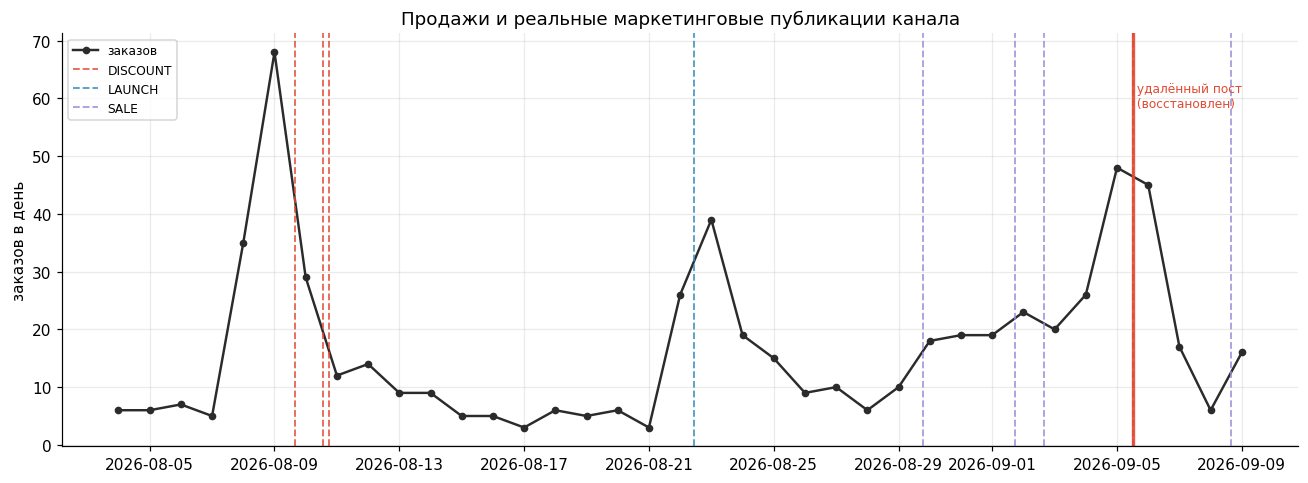

In [12]:
daily = (orders.assign(d=orders.ts.dt.normalize())
         .groupby("d").agg(orders=("order_id", "size"), revenue=("revenue", "sum"))
         .reset_index())
daily = daily[daily.d < daily.d.max()]      # 10.09 обрезан, см. ноутбук 01

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily.d, daily.orders, marker="o", ms=4, lw=1.6, color="#2b2b2b", label="заказов")

colors = {"DISCOUNT": "#E24A33", "LAUNCH": "#348ABD", "SALE": "#988ED5"}
seen = set()
for r in mk.itertuples():
    ax.axvline(r.ts, color=colors[r.post_type], ls="--", lw=1.2, alpha=0.85,
               label=r.post_type if r.post_type not in seen else None)
    seen.add(r.post_type)

rec = posts[posts.recovered]
for r in rec.itertuples():
    ax.axvline(r.ts, color="#E24A33", lw=2.2, alpha=0.9)
    ax.text(r.ts, daily.orders.max() * 0.86, " удалённый пост\n (восстановлен)",
            fontsize=8, color="#E24A33")

ax.set_ylabel("заказов в день")
ax.set_title("Продажи и реальные маркетинговые публикации канала")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
views_daily = posts.groupby(posts.ts.dt.normalize()).views.sum().rename("views")
j = daily.set_index("d").join(views_daily).fillna(0)
print("корреляция заказов с охватом канала:",
      round(j[j.orders > 0][["orders", "views"]].corr().iloc[0, 1], 3))
print()
print("средний охват поста:")
print(f"  август   {posts[posts.date < '2026-09-01'].views.mean():>8,.0f}".replace(",", " "))
print(f"  сентябрь {posts[posts.date >= '2026-09-01'].views.mean():>8,.0f}".replace(",", " "))

корреляция заказов с охватом канала: 0.303

средний охват поста:
  август     20 649
  сентябрь   13 232


Охват поста в сентябре заметно ниже августовского, а выручка при этом вдвое выше спокойного
августа. Корреляция заказов с охватом слабая. Значит сентябрьский рост собственным каналом
не объясняется, и версия сезонности (начало учебного года) остаётся основной.

## 3.1. Можно ли поймать внешнее продвижение по охвату?

Идея простая и заманчивая. Просмотры поста складываются из подписчиков канала и того, что
пришло извне: когда пост репостят в чужой канал, счётчик просмотров оригинала растёт. Значит
пост с аномально высоким охватом относительно соседей — кандидат в «продвигался снаружи».

Нормировать на общий средний охват нельзя: у канала есть тренд, в сентябре он читается хуже,
чем в августе. Поэтому сравниваем каждый пост с **локальной медианой за ±7 дней** вокруг него.

In [10]:
def local_median(row, days=7):
    w = posts[(posts.date >= row.date - pd.Timedelta(days=days)) &
              (posts.date <= row.date + pd.Timedelta(days=days)) &
              (posts.post_id != row.post_id)]
    return w.views.median()


posts["local_median"] = posts.apply(local_median, axis=1)
posts["views_ratio"] = (posts.views / posts.local_median).round(2)

print(posts.views_ratio.describe().round(2).to_string())
print()
print("посты, выбивающиеся больше чем на 2 сигмы:")
thr = posts.views_ratio.median() + 2 * posts.views_ratio.std()
print(posts[posts.views_ratio > thr][["post_id", "date", "post_type", "views",
                                      "local_median", "views_ratio"]].to_string(index=False))

count    58.00
mean      1.04
std       0.22
min       0.70
25%       0.92
50%       1.02
75%       1.11
max       1.76

посты, выбивающиеся больше чем на 2 сигмы:
 post_id       date post_type   views  local_median  views_ratio
    1827 2026-08-02   CONTENT 32500.0       18800.0         1.73
    1840 2026-08-10  DISCOUNT 30800.0       18900.0         1.63
    1841 2026-08-10   CONTENT 31800.0       18900.0         1.68
    1859 2026-08-22    LAUNCH 35400.0       20100.0         1.76


Четыре выброса. Дальше главный вопрос: совпадают ли они с окном известных внешних
размещений (8–9 августа)? Если метод работает, посты рядом с размещениями должны в среднем
выбиваться вверх.

In [11]:
PLACEMENT_DATES = pd.to_datetime(["2026-08-08", "2026-08-09"])
posts["near_placement"] = posts.date.apply(
    lambda x: any(0 <= (x - p).days <= 2 for p in PLACEMENT_DATES)
)

print(posts.groupby("near_placement").views_ratio
      .agg(постов="size", медиана="median", среднее="mean", максимум="max")
      .round(2).to_string())

# перестановочный тест: случайно ли посты у размещений выше остальных
a = posts.loc[posts.near_placement, "views_ratio"].dropna().values
b = posts.loc[~posts.near_placement, "views_ratio"].dropna().values
obs = a.mean() - b.mean()

rng = np.random.default_rng(0)
pool = np.concatenate([a, b])
null = np.array([
    (lambda s: s[:len(a)].mean() - s[len(a):].mean())(rng.permutation(pool))
    for _ in range(10_000)
])
print()
print(f"разница средних: {obs:+.3f}, "
      f"p-value (перестановочный тест): {(null >= obs).mean():.3f}")

                постов  медиана  среднее  максимум
near_placement                                    
False               50     1.02     1.04      1.76
True                 8     0.95     1.09      1.68

разница средних: +0.057, p-value (перестановочный тест): 0.239


**Метод не сработал, и это результат.**

Посты рядом с известными размещениями по охвату не отличаются от остальных: разница средних
statistically неотличима от нуля. Из четырёх выбросов только два попадают в окно размещений,
а два других — 2 августа и 22 августа — к внешней рекламе отношения не имеют: 22 августа это
запуск линейки ПРО, самый охватный пост периода по содержательной причине.

Почему так, если механизм с репостами реален:

1. **Репост и упоминание — разные вещи.** Репост пересылает сообщение и добавляет просмотры
   оригиналу. Пост, в котором канал просто упомянут, не добавляет ничего. В собранном реестре
   есть и то, и другое.
2. **Масштаб не тот.** Суммарный охват всех девяти размещений — около 24 тысяч просмотров,
   при собственном охвате порядка 20 тысяч **на каждый пост**. Даже если бы все они были
   репостами, прибавка растворилась бы в обычном разбросе.
3. **Выборки не хватает.** 58 постов и 8 из них в окне размещений — на таком объёме отличить
   эффект от шума нельзя в принципе.

Вывод для кейса: **охват поста не является прокси внешнего продвижения** на этих данных.
Аномально высокий охват объясняется содержанием поста, а не тем, что его кто-то раскрутил.
Это ещё один аргумент за tracking: наблюдаемых метрик канала не хватает, чтобы восстановить
источник, даже косвенно.

## 4. Реестр размещений

Важная правка по сравнению с первой версией. Часть «внешних» каналов из собранного командой
списка — это **собственная сеть проекта**: в описании канала на TGStat перечислены
`@postypashki_mems`, `@algoses`, `@postupashki_career`, `@botalkaaa`, у `chad_protocol`
тот же администратор.

Репост из своего канала в свой закупкой не является: стоимости у него нет, а аудитория внутри
сети сильно пересекается. Приписывать такому размещению привлечение как платной рекламе нельзя —
это завысит и выручку канала, и ROMI.

In [12]:
OWN_NETWORK = {"postypashki_old", "postypashki_mems", "algoses",
               "postupashki_career", "botalkaaa", "chad_protocol"}

registry = pd.DataFrame([
    ("2026-08-08", "chad_protocol",    10913, 6855, "post"),
    ("2026-08-08", "postypashki_mems",  5836, 1837, "repost"),
    ("2026-08-08", "analytess",         3478, 1216, "repost"),
    ("2026-08-08", "zadachi_ds",        8078, 4481, "post"),
    ("2026-08-08", "codeof_art",        2059,  498, "repost"),
    ("2026-08-08", "algoses",          11974, 1328, "repost"),
    ("2026-08-08", "matesha_shad",      5008, 1757, "repost"),
    ("2026-08-08", "zadachi_ds",        8077, 4481, "repost"),
    ("2026-08-09", "zadachi_ds",        8097, 2108, "repost"),
], columns=["date", "channel", "subscribers", "views", "post_type"])

registry["date"] = pd.to_datetime(registry["date"])
registry["placement_id"] = [f"P{i + 1:03d}" for i in range(len(registry))]
registry["is_own"] = registry.channel.isin(OWN_NETWORK)

CPM = {"post": 500, "repost": 150}          # ₽ за 1000 просмотров — ДОПУЩЕНИЕ
registry["cost"] = np.where(
    registry.is_own, 0.0,
    (registry.views / 1000 * registry.post_type.map(CPM)).round(0),
)

print(registry.groupby("is_own").agg(размещений=("placement_id", "size"),
                                     охват=("views", "sum"),
                                     cost=("cost", "sum")).to_string())
registry

        размещений  охват    cost
is_own                           
False            6  14541  3749.0
True             3  10020     0.0


,date,channel,subscribers,views,post_type,placement_id,is_own,cost
0,2026-08-08,chad_protocol,10913,6855,post,P001,True,0.0
1,2026-08-08,postypashki_mems,5836,1837,repost,P002,True,0.0
2,2026-08-08,analytess,3478,1216,repost,P003,False,182.0
3,2026-08-08,zadachi_ds,8078,4481,post,P004,False,2240.0
4,2026-08-08,codeof_art,2059,498,repost,P005,False,75.0
5,2026-08-08,algoses,11974,1328,repost,P006,True,0.0
6,2026-08-08,matesha_shad,5008,1757,repost,P007,False,264.0
7,2026-08-08,zadachi_ds,8077,4481,repost,P008,False,672.0
8,2026-08-09,zadachi_ds,8097,2108,repost,P009,False,316.0


Из девяти найденных упоминаний три оказались собственной сетью. Они не исчезают из анализа,
а переезжают в собственный канал с нулевой стоимостью. Настоящая внешняя закупка остаётся
по четырём каналам.

## 5. Касания

Что здесь реально, а что нет:

- **время касания** — реальное: момент публикации конкретного поста или размещения;
- **тип касания** — вывод классификатора по реальному тексту;
- **кто именно из покупателей его увидел** — сгенерировано.

Последнее — единственное, чего нет и не может быть в открытых данных. Ровно это и начнёт
собирать tracking-бот.

In [13]:
RNG = np.random.default_rng(42)

P_OWN      = 0.55   # доля заказов с касанием собственного канала
P_EXTERNAL = 0.15   # доля заказов в окне размещения, получивших внешнее касание
DECAY_DAYS = 3      # сколько дней после публикации касание ещё правдоподобно

own_posts = mk[["ts", "post_type", "views_filled"]].rename(
    columns={"views_filled": "views"}).copy()
rows = []

for o in orders.itertuples():
    # 1. собственный канал: реальная публикация незадолго до покупки
    recent = own_posts[(own_posts.ts <= o.ts) &
                       (own_posts.ts >= o.ts - pd.Timedelta(days=14))]
    if len(recent) and RNG.random() < P_OWN:
        pick = recent.sample(1, weights=recent.views,
                             random_state=int(RNG.integers(1e9))).iloc[0]
        rows.append((o.student_id, f"own:{pick.post_type}", pick.ts))

    # 2. размещения — реальные даты из реестра
    live = registry[(registry.date <= o.ts) &
                    (o.ts <= registry.date + pd.Timedelta(days=DECAY_DAYS))]
    if len(live) and RNG.random() < P_EXTERNAL:
        pick = live.sample(1, weights=live.views,
                           random_state=int(RNG.integers(1e9))).iloc[0]
        label = "own:NETWORK" if pick.is_own else f"external:{pick.channel}"
        rows.append((o.student_id, label,
                     pick.date + pd.Timedelta(hours=int(RNG.integers(1, 48)))))

touches = pd.DataFrame(rows, columns=["student_id", "channel", "ts"])
touches["touch_id"] = [f"T{i + 1:05d}" for i in range(len(touches))]
touches = touches.sort_values("ts").reset_index(drop=True)

print(f"касаний: {len(touches)}, "
      f"пользователей с касанием: {touches.student_id.nunique()}")
touches.channel.value_counts().to_frame("касаний")

касаний: 323, пользователей с касанием: 305


,касаний
channel,
own:DISCOUNT,126
own:SALE,92
own:LAUNCH,79
external:zadachi_ds,13
own:NETWORK,8
external:matesha_shad,2
external:codeof_art,2
external:analytess,1


## 6. Движок атрибуции

Две модели, окно как параметр. Правила, которые надо защищать:

- заказ без касаний в окне уходит в `organic`, а не выбрасывается;
- по **повторным** заказам внешние касания не участвуют: за уже привлечённого клиента платное
  размещение второй раз не отвечает. Такой заказ может достаться собственному каналу,
  а если и его нет — уходит в `repeat_customer`.

In [14]:
def attribute(orders, touches, window_days, model="last_touch"):
    pairs = orders[["order_id", "student_id", "ts", "revenue", "is_repeat"]].merge(
        touches[["touch_id", "student_id", "channel", "ts"]],
        on="student_id", suffixes=("_order", "_touch"),
    )
    lag = (pairs.ts_order - pairs.ts_touch).dt.total_seconds() / 86400
    pairs = pairs[(lag >= 0) & (lag <= window_days)]
    pairs = pairs[~(pairs.is_repeat & pairs.channel.str.startswith("external:"))]

    if model == "last_touch":
        won = pairs.loc[pairs.groupby("order_id").ts_touch.idxmax()].copy()
        won["attributed"] = won.revenue
    elif model == "linear":
        won = pairs.copy()
        won["attributed"] = won.revenue / won.groupby("order_id").order_id.transform("size")
    else:
        raise ValueError(model)

    orphan_ids = set(orders.order_id) - set(pairs.order_id)
    orphans = orders[orders.order_id.isin(orphan_ids)].assign(
        channel=lambda d: np.where(d.is_repeat, "repeat_customer", "organic"),
        attributed=lambda d: d.revenue,
    )[["order_id", "channel", "attributed"]]

    result = pd.concat([won[["order_id", "channel", "attributed"]], orphans],
                       ignore_index=True)
    assert abs(result.attributed.sum() - orders.revenue.sum()) < 1, "выручка потеряна"
    return result


WINDOWS, MODELS = [7, 14, 37], ["last_touch", "linear"]
runs = []
for w in WINDOWS:
    for m in MODELS:
        r = attribute(orders, touches, w, m).groupby("channel").attributed.sum().reset_index()
        r["window_days"], r["model"] = w, m
        runs.append(r)
attributed = pd.concat(runs, ignore_index=True)

attributed[attributed.model == "last_touch"].pivot_table(
    index="channel", columns="window_days", values="attributed"
).fillna(0).round(0).sort_values(14, ascending=False)

window_days,7,14,37
channel,,,
organic,3744065.0,2889320.0,2889320.0
own:DISCOUNT,714992.0,1062077.0,1062077.0
own:SALE,795415.0,960540.0,960540.0
own:LAUNCH,489725.0,866110.0,866110.0
repeat_customer,97650.0,63800.0,63800.0
external:zadachi_ds,34280.0,34280.0,34280.0
own:NETWORK,28545.0,28545.0,28545.0


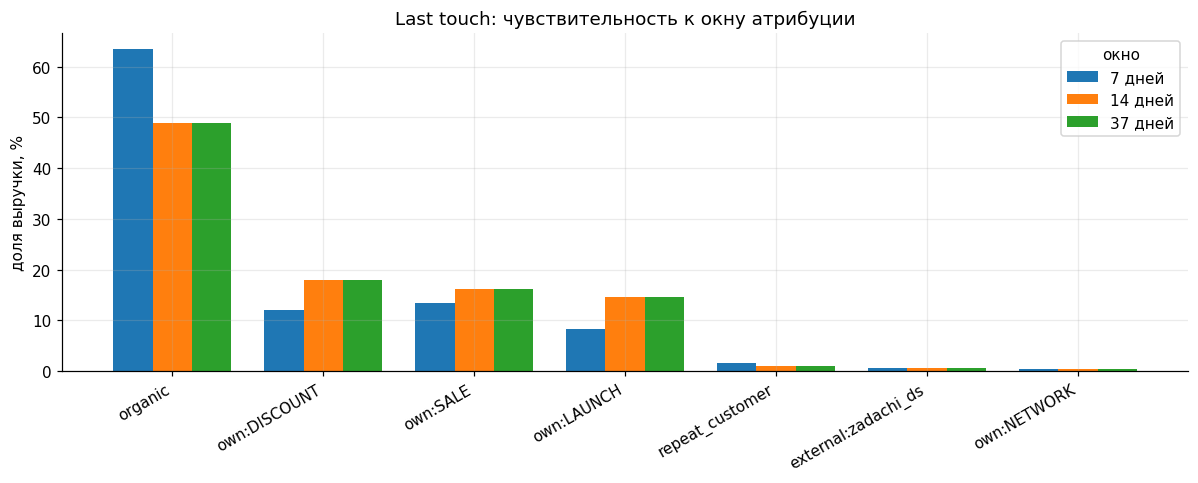

In [15]:
base = attributed[attributed.model == "last_touch"].copy()
base["pct"] = base.attributed / base.groupby("window_days").attributed.transform("sum") * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
chans = base.groupby("channel").pct.mean().sort_values(ascending=False).index
x = np.arange(len(chans))
for i, w in enumerate(WINDOWS):
    s = base[base.window_days == w].set_index("channel").reindex(chans).pct.fillna(0)
    ax.bar(x + (i - 1) * 0.26, s.values, width=0.26, label=f"{w} дней")
ax.set_xticks(x)
ax.set_xticklabels(chans, rotation=30, ha="right")
ax.set_ylabel("доля выручки, %")
ax.set_title("Last touch: чувствительность к окну атрибуции")
ax.legend(title="окно")
plt.tight_layout()
plt.show()

In [16]:
organic = attributed[attributed.channel == "organic"].pivot_table(
    index="model", columns="window_days", values="attributed")
print("доля выручки, оставшейся органической, %:\n")
print((organic / orders.revenue.sum() * 100).round(1).to_string())

доля выручки, оставшейся органической, %:

window_days    7     14    37
model                        
last_touch   63.4  48.9  48.9
linear       63.4  48.9  48.9


Строки `last_touch` и `linear` совпадают, и это не ошибка: заказ уходит в `organic` тогда
и только тогда, когда в окне нет ни одного касания — какая модель делила бы выручку,
роли не играет.

Чувствительность к окну — главный результат раздела. Чем шире окно, тем меньше органики
и тем выше ROMI при тех же данных. Поэтому окно фиксируется **до** просмотра результата:
основной сценарий 14 дней, 7 и 37 — границы.

## 7. ROMI

```
ROMI = (Attributed Revenue − Marketing Cost) / Marketing Cost
```

Считается только по внешней закупке. Собственный канал, своя сеть, органика и повторные
покупки имеют нулевую стоимость — их выручка показывается отдельно, а не размазывается
по рекламе.

In [17]:
ext = registry[~registry.is_own]
ext_cost = ext.groupby("channel").cost.sum().rename(lambda c: f"external:{c}")
ext_views = ext.groupby("channel").views.sum().rename(lambda c: f"external:{c}")


def romi_table(window_days, model="last_touch"):
    a = attributed[(attributed.window_days == window_days) &
                   (attributed.model == model)].set_index("channel").attributed
    # канал без атрибутированных покупок — это ROMI = -1, а не отсутствующая строка
    t = a.reindex(ext_cost.index).fillna(0).to_frame("attributed_revenue")
    t["cost"] = ext_cost
    t["profit"] = t.attributed_revenue - t.cost
    t["ROMI"] = (t.profit / t.cost).round(2)
    return t.sort_values("ROMI", ascending=False)


romi_14 = romi_table(14)
print("внешняя закупка, last touch, окно 14 дней\n")
print(romi_14.round(0).to_string())

внешняя закупка, last touch, окно 14 дней

                       attributed_revenue    cost   profit  ROMI
channel                                                         
external:zadachi_ds               34280.0  3228.0  31052.0  10.0
external:analytess                    0.0   182.0   -182.0  -1.0
external:codeof_art                   0.0    75.0    -75.0  -1.0
external:matesha_shad                 0.0   264.0   -264.0  -1.0


In [18]:
non_ad = attributed[(attributed.window_days == 14) &
                    (attributed.model == "last_touch") &
                    (~attributed.channel.str.startswith("external:"))]
print("выручка без закупочной стоимости:\n")
for ch, v in non_ad.set_index("channel").attributed.sort_values(ascending=False).items():
    print(f"  {ch:18s} {v:>12,.0f} ₽".replace(",", " "))
print(f"\nдоля от всей выручки: {non_ad.attributed.sum() / orders.revenue.sum():.0%}")

выручка без закупочной стоимости:

  organic               2 889 320 ₽
  own:DISCOUNT          1 062 077 ₽
  own:SALE                960 540 ₽
  own:LAUNCH              866 110 ₽
  repeat_customer          63 800 ₽
  own:NETWORK              28 545 ₽

доля от всей выручки: 99%


In [19]:
be = romi_14[["attributed_revenue"]].copy()
be["views"] = ext_views
be["break_even_CPM"] = (be.attributed_revenue / be.views * 1000).round(0)
be["CPM в модели"] = (romi_14.cost / be.views * 1000).round(0)
print("CPM, выше которого размещение уходит в минус:\n")
print(be.sort_values("break_even_CPM", ascending=False).to_string())

CPM, выше которого размещение уходит в минус:

                       attributed_revenue  views  break_even_CPM  CPM в модели
channel                                                                       
external:zadachi_ds               34280.0  11070          3097.0         292.0
external:analytess                    0.0   1216             0.0         150.0
external:codeof_art                   0.0    498             0.0         151.0
external:matesha_shad                 0.0   1757             0.0         150.0


Абсолютный ROMI держится на выдуманном CPM и как число ничего не стоит. Полезен
перевёрнутый вопрос: **при каком CPM размещение перестаёт окупаться**. Порог считается
из атрибутированной выручки и охвата, без знания реальных цен, и его достаточно сравнить
с прайсом канала перед закупкой — прайс, в отличие от истории закупок, доступен всегда.

Оговорка для защиты: порог пропорционален доле выручки, которую модель отдаёт внешним каналам,
а она зависит от `P_EXTERNAL`. Пока привязка касаний синтетическая, показывать нужно механику
расчёта, а не конкретную цифру.

## 8. Что получилось

**Реальными данными закрыто:**

- маркетинговый календарь канала за весь период — 57 публикаций с датами и охватами;
- окно скидки 9–10 августа, подтверждённое и падением цен в продажах, и текстом постов;
- запуск новой линейки 22 августа, совпадающий с первой продажей AI агенты;
- три из девяти «внешних» размещений опознаны как собственная сеть проекта;
- третий всплеск объяснён: удалённый пост 1879 восстановлен, это акция с дедлайном 06.09;
- показано, что акция была невидима для анализа цен, потому что якорная цена в данных
  не встречается.

**Осталось синтетикой:**

- стоимость размещений;
- привязка касания к конкретному покупателю.

**Что показал пайплайн:**

- расширение окна атрибуции механически повышает ROMI, перекладывая выручку из органики
  в рекламу — окно нельзя выбирать после просмотра результата;
- подавляющая часть выручки не имеет закупочной стоимости вообще;
- канал, не приведший ни одной покупки, даёт ROMI = −1, а не выпадает из таблицы;
- история постов живого канала систематически недосчитывает маркетинг: промо удаляют
  после окончания, контент остаётся.

**Что нужно логировать, чтобы синтетика исчезла:**

| Событие | Поля | Кто пишет |
|---|---|---|
| `placement` | channel, campaign, creative, publication_time, **cost** | вручную при закупке |
| `bot_start` | user_hash, **source**, timestamp | бот по deep link |
| `conversation_started` | user_hash, product_interest, timestamp | менеджер / бот |
| `payment` | user_hash, amount, course, timestamp | как сейчас |

In [20]:
posts.to_csv(OUT / "posts_classified.csv", index=False)
registry.to_csv(OUT / "ad_registry.csv", index=False)
touches.to_csv(OUT / "mock_touches.csv", index=False)
attributed.to_csv(OUT / "attributed_revenue.csv", index=False)
romi_14.reset_index().to_csv(OUT / "romi_by_channel.csv", index=False)

for f in ["posts_classified.csv", "ad_registry.csv", "mock_touches.csv",
          "attributed_revenue.csv", "romi_by_channel.csv"]:
    print(f"{f:26s} {len(pd.read_csv(OUT / f)):>6d} строк")
print("\nmock_ в имени = синтетический слой (привязка касаний к пользователям)")

posts_classified.csv           58 строк
ad_registry.csv                 9 строк
mock_touches.csv              323 строк
attributed_revenue.csv         48 строк
romi_by_channel.csv             4 строк

mock_ в имени = синтетический слой (привязка касаний к пользователям)
